# EDA — e-nose sensor curves

Exploratory data analysis of piezo-sensor measurements for the e-nose framework.

**Scope & honesty note.** This notebook runs on the **20 test measurements** currently available,
not the labelled medical dataset. With ~20 points and no clinical labels, the goal
here is **methodological**: show that the ingestion -> feature-extraction ->
analysis pipeline works and that the sensors discriminate between substances.
It is **not** a statistical study of the substances themselves. Once the large
labelled dataset is provided, the same pipeline scales to real analysis.

## 1. Setup & data loading

In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

_src = Path.cwd().parent / "src"
if _src.exists() and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from features import build_feature_table  # noqa: E402

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = os.environ.get("ENOSE_DATA", "../data")
print("data dir:", DATA_DIR)

data dir: /mnt/user-data/uploads


## 2. Build the feature table

Each measurement (8 sensors × ~300 points) is reduced to a flat row of
per-sensor curve features: peak deflection, time-to-peak, area under curve,
initial slope, end value, fall-back from peak, and roughness.

In [2]:
feat = build_feature_table(DATA_DIR)
print(feat.shape)
feat[["name", "file"]].head(20)

(20, 66)


,name,file
0,капля воды,капля_воды
1,лед с гидролатом эвкалипта 1,лед_с_гидролатом_эвкалипта
2,лед с духами1,лед_с_духами
3,лед с маслом и экстрактом,лед_с_маслом_и_экстрактом
4,лед чистый 600 с,лед_чистый
5,Базилик,масло_базилика
6,герань,масло_герани
7,жасмин,масло_жасмина
8,кедр москва,масло_кедра
9,корица,масло_корицы


## 3. Data quality check\n\nHow many sensors actually responded per measurement, and are there flat/near-dead measurements?

In [3]:
# max absolute deflection per sensor, wide -> long for inspection
max_cols = [c for c in feat.columns if c.endswith("_max_abs")]
maxes = feat[["name"] + max_cols].copy()
maxes.columns = ["name"] + [c.replace("_max_abs", "") for c in max_cols]
maxes_long = maxes.melt(id_vars="name", var_name="sensor", value_name="max_abs")

# overall signal strength per measurement
strength = maxes_long.groupby("name")["max_abs"].sum().sort_values(ascending=False)
print("Total signal strength per measurement (sum of sensor peaks):")
print(strength)

Total signal strength per measurement (sum of sensor peaks):
name
мясо вареное                    835.0
лед с духами1                   309.0
лед с маслом и экстрактом       184.0
шалфей                          150.0
жасмин                          137.0
лед чистый 600 с                125.0
лед с гидролатом эвкалипта 1    121.0
масло мандарина                 112.0
слезы                            94.0
ромашка                          80.0
можжевельник                     78.0
мята россия                      74.0
пальмароза                       69.0
лаванда крымская                 67.0
герань                           62.0
кедр москва                      50.0
нероли                           46.0
Базилик                          44.0
капля воды                       29.0
корица                           24.0
Name: max_abs, dtype: float64


**Reading it.** Measurements at the bottom of this list (very low total
signal) are weak responders — candidates the device's quality filter would
likely flag. This is exactly the kind of screening the pipeline enables.

## 4. Which sensors carry the signal?

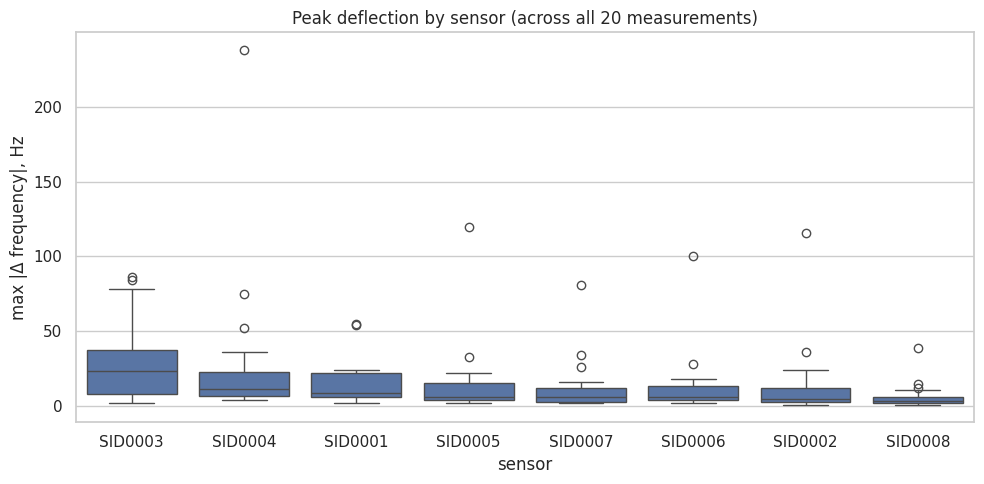

In [4]:
plt.figure(figsize=(10, 5))
order = (
    maxes_long.groupby("sensor")["max_abs"].median().sort_values(ascending=False).index
)
sns.boxplot(data=maxes_long, x="sensor", y="max_abs", order=order)
plt.title("Peak deflection by sensor (across all 20 measurements)")
plt.ylabel("max |Δ frequency|, Hz")
plt.xlabel("sensor")
plt.tight_layout()
plt.show()

Some sensors consistently respond more strongly than others. The sensor
with the highest median deflection is the most informative single channel for
this set of substances — useful to know for later feature selection.

## 5. Substance fingerprints (sensor heatmap)

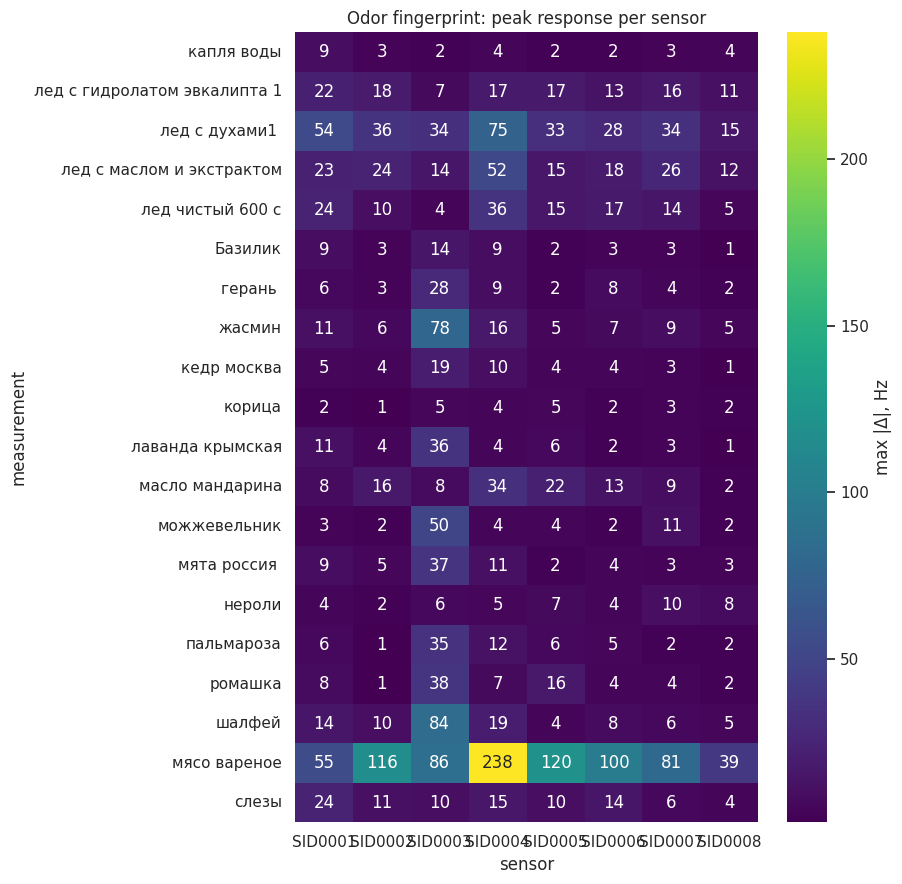

In [5]:
# heatmap: measurement x sensor, value = peak deflection
hm = maxes.set_index("name")
plt.figure(figsize=(9, 9))
sns.heatmap(
    hm, annot=True, fmt=".0f", cmap="viridis", cbar_kws={"label": "max |Δ|, Hz"}
)
plt.title("Odor fingerprint: peak response per sensor")
plt.xlabel("sensor")
plt.ylabel("measurement")
plt.tight_layout()
plt.show()

Each **row is a substance's fingerprint** across the 8 sensors. Distinct
row patterns mean the e-nose separates substances — e.g. some are dominated by
a single sensor, others spread across several. This visual is the core argument
that classification is feasible on real data.

## 6. Group comparison: oils vs ice vs other

A coarse grouping from the file names (demonstrative — not a statistical test at n≈20).

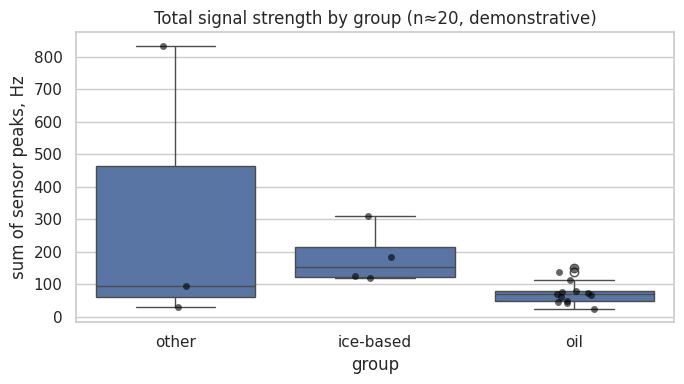

group
oil          13
ice-based     4
other         3
Name: count, dtype: int64

In [6]:
def group_of(name):
    n = name.lower()
    if "лед" in n or "лёд" in n:
        return "ice-based"
    if "масло" in n or any(
        o in n
        for o in [
            "шалфей",
            "жасмин",
            "герань",
            "корица",
            "мята",
            "нероли",
            "ромашка",
            "кедр",
            "базилик",
            "лаванда",
            "можжевельник",
            "пальмароза",
            "мандарин",
        ]
    ):
        return "oil"
    return "other"


feat["group"] = feat["name"].map(group_of)
g_strength = feat.assign(total=feat[max_cols].sum(axis=1))[["group", "total"]]
plt.figure(figsize=(7, 4))
sns.boxplot(data=g_strength, x="group", y="total")
sns.stripplot(data=g_strength, x="group", y="total", color="black", alpha=0.6)
plt.title("Total signal strength by group (n≈20, demonstrative)")
plt.ylabel("sum of sensor peaks, Hz")
plt.tight_layout()
plt.show()
feat["group"].value_counts()

## 7. Do measurements cluster? (PCA)

Project the 64-dim feature space to 2D to see whether similar substances land near each other.

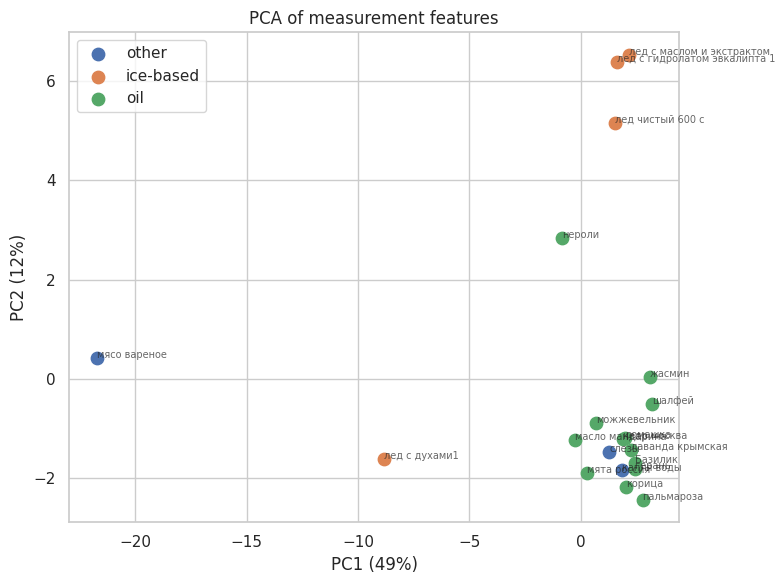

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

num = feat.drop(columns=["name", "file", "group"]).fillna(0.0)
X = StandardScaler().fit_transform(num)
pca = PCA(n_components=2, random_state=0)
xy = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
for grp in feat["group"].unique():
    m = feat["group"].values == grp
    plt.scatter(xy[m, 0], xy[m, 1], label=grp, s=80)
for i, nm in enumerate(feat["name"]):
    plt.annotate(nm, (xy[i, 0], xy[i, 1]), fontsize=7, alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.0f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.0f}%)")
plt.title("PCA of measurement features")
plt.legend()
plt.tight_layout()
plt.show()

**Reading it.** Even on 20 points, related measurements tend to fall in
similar regions, while strong/unusual ones (e.g. very high single-sensor
response) sit apart. This is encouraging for classification — but with n≈20 it
is *indicative*, not conclusive.

## 8. Summary & next steps

**What this EDA establishes**
- The full pipeline works end-to-end: XML -> long-form -> 64 curve features -> analysis.
- Sensors carry different amounts of signal; a few channels dominate.
- Each substance has a distinguishable multi-sensor fingerprint.
- Measurements show early signs of grouping in feature space.

**Limitations (stated plainly)**
- Only ~20 reference measurements; no clinical labels.
- Group comparisons are demonstrative, not statistically powered.
